In [1]:
import pandas as pd

df = pd.read_csv("Tweets.csv")

In [2]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [4]:
df.shape

(27481, 4)

In [5]:
##keep required columns
df = df[['text','sentiment']].copy()

df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [6]:
##check missing values
df.isnull().sum()

text         1
sentiment    0
dtype: int64

In [7]:
##remove missing values
df.dropna(inplace=True)

In [8]:
#class istribution
df['sentiment'].value_counts()


sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

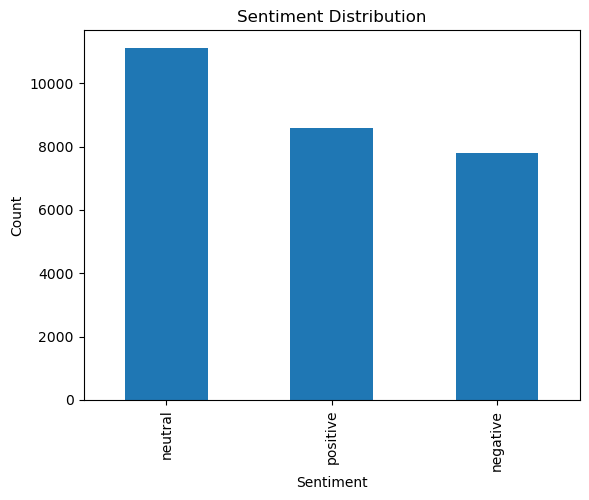

In [9]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [10]:
##install nltk
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
##import libraries
import re

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [12]:
##test cleaning
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

# Keep negation words — removing them breaks phrases like "not bad"
negation_words = {"not", "no", "nor", "never", "n't"}
custom_stopwords = stop_words - negation_words

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"[^a-zA-Z ]","",text)

    words = text.split()

    words = [word for word in words
             if word not in custom_stopwords]

    words = [lemmatizer.lemmatize(word)
             for word in words]

    return " ".join(words)

In [13]:
##cleaning
df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df.head()

,text,sentiment,clean_text
0,"I`d have responded, if I were going",neutral,id responded going
1,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad miss san diego
2,my boss is bullying me...,negative,bos bullying
3,what interview! leave me alone,negative,interview leave alone
4,"Sons of ****, why couldn`t they put them on t...",negative,son couldnt put release already bought


In [15]:
##labels to numeric
mapping = {
    'positive':1,
    'neutral':0,
    'negative':-1
}

df['label'] = df['sentiment'].map(mapping)

In [16]:
##TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# ngram_range=(1,2) captures both single words AND two-word phrases
# like "not bad" as individual features, preserving negation context
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = tfidf.fit_transform(df['clean_text'])

y = df['label']

In [17]:
#train-test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
##Logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.6914119359534207


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.73      0.61      0.67      1556
           0       0.62      0.75      0.68      2223
           1       0.79      0.69      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



In [22]:
##Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[ 952  558   46]
 [ 292 1667  264]
 [  59  477 1181]]


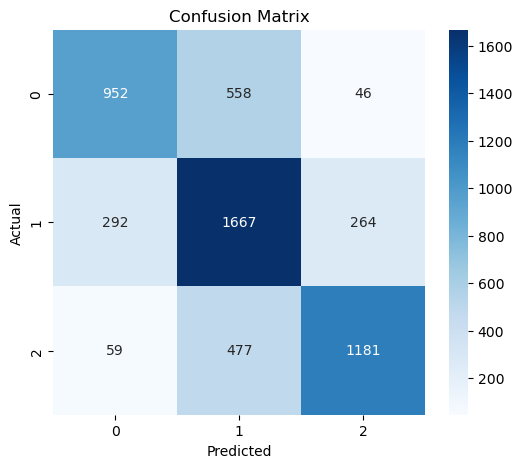

In [23]:
##Ploting confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_SA.png", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
##test sentences
samples = [
    "Excellent teaching and supportive faculty",
    "The teaching is okay",
    "Very poor laboratory facilities"
]

for text in samples:

    clean = clean_text(text)

    vector = tfidf.transform([clean])

    pred = model.predict(vector)

    print(text,"->",pred[0])

Excellent teaching and supportive faculty -> 1
The teaching is okay -> 0
Very poor laboratory facilities -> -1


In [25]:
##Model saving
import joblib

joblib.dump(model,'best_sentiment_model.pkl')

joblib.dump(tfidf,'tfidf.pkl')

['tfidf.pkl']

In [26]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.6914119359534207


In [27]:
##Navie bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(y_test, pred_nb)

print("Naive Bayes:", nb_acc)
print(classification_report(y_test, pred_nb))

Naive Bayes: 0.6430131004366813
              precision    recall  f1-score   support

          -1       0.72      0.51      0.60      1556
           0       0.56      0.77      0.65      2223
           1       0.77      0.60      0.67      1717

    accuracy                           0.64      5496
   macro avg       0.68      0.63      0.64      5496
weighted avg       0.67      0.64      0.64      5496



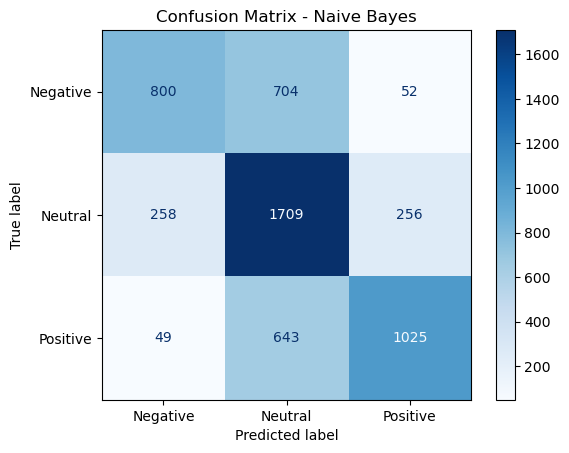

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm1 = confusion_matrix(y_test, pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [29]:
#SVM
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, pred_svm)

print("SVM:", svm_acc)
print(classification_report(y_test, pred_svm))

SVM: 0.6786754002911208
              precision    recall  f1-score   support

          -1       0.69      0.65      0.67      1556
           0       0.63      0.67      0.65      2223
           1       0.74      0.71      0.73      1717

    accuracy                           0.68      5496
   macro avg       0.69      0.68      0.68      5496
weighted avg       0.68      0.68      0.68      5496



In [30]:
models = [
    "Logistic Regression",
    "Naive Bayes",
    "SVM"
]

scores = [
    lr_acc,
    nb_acc,
    svm_acc
]

for m, s in zip(models, scores):
    print(m, ":", round(s*100, 2), "%")

Logistic Regression : 69.14 %
Naive Bayes : 64.3 %
SVM : 67.87 %


In [31]:
best_model = models[scores.index(max(scores))]
print("Best Model:", best_model)

Best Model: Logistic Regression


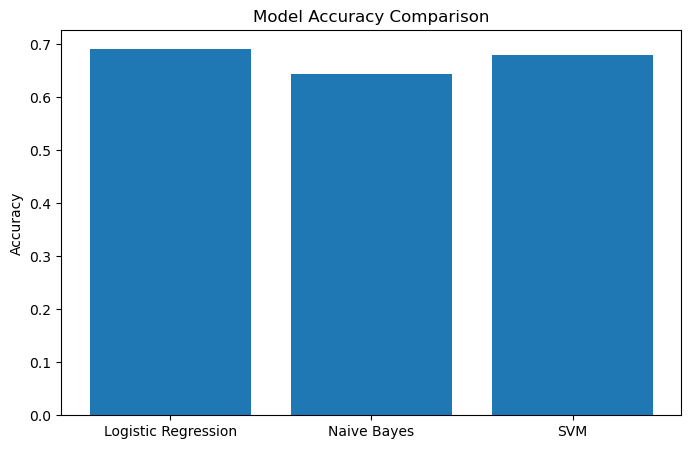

In [32]:
##model comparison graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.savefig("model_comparison.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [33]:
import joblib

loaded_model = joblib.load("best_sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf.pkl")

In [34]:
text = "This movie was terrible."
cleaned_text = clean_text(text)
text_vector = loaded_tfidf.transform([cleaned_text])
prediction = loaded_model.predict(text_vector)
print(prediction)

[-1]


In [35]:
label_map = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}

print("Input:", text)
print("Predicted Sentiment:", label_map[prediction[0]])

Input: This movie was terrible.
Predicted Sentiment: Negative


In [36]:
text = "The service was okay"
cleaned_text = clean_text(text)
text_vector = loaded_tfidf.transform([cleaned_text])
prediction = loaded_model.predict(text_vector)
print(prediction)

[0]


In [37]:
text = "The product is amazing and I really loved it."
cleaned_text = clean_text(text)
text_vector = loaded_tfidf.transform([cleaned_text])
prediction = loaded_model.predict(text_vector)
print(prediction)

[1]


In [38]:
text = "The movie was not bad"
cleaned = clean_text(text)
print("Cleaned:", cleaned)

vector = tfidf.transform([cleaned])
pred = model.predict(vector)

label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
print("Prediction:", label_map[pred[0]])

Cleaned: movie not bad
Prediction: Neutral


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Wrap your existing clean_text function so it works inside a Pipeline
def clean_batch(texts):
    return [clean_text(t) for t in texts]

pipeline = Pipeline([
    ('clean', FunctionTransformer(clean_batch)),
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train it on the ORIGINAL text column (not the pre-cleaned one)
pipeline.fit(df['text'], df['label'])

# Quick sanity check
print(pipeline.predict(["The movie was not bad"]))
print(pipeline.predict(["This is terrible"]))

[0]
[-1]


In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, df['text'], df['label'], cv=5, scoring='f1_macro')
print("F1 scores per fold:", scores)
print(f"Mean F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

F1 scores per fold: [0.69402925 0.69188966 0.69557445 0.69436678 0.69354201]
Mean F1: 0.694 (+/- 0.001)


In [41]:
# Same pipeline but with class_weight balanced
pipeline_balanced = Pipeline([
    ('clean', FunctionTransformer(clean_batch)),
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

scores_balanced = cross_val_score(pipeline_balanced, df['text'], df['label'], cv=5, scoring='f1_macro')
print(f"Balanced Mean F1: {scores_balanced.mean():.3f} (+/- {scores_balanced.std():.3f})")

print(f"\nComparison:")
print(f"Without class_weight: {scores.mean():.3f}")
print(f"With class_weight='balanced': {scores_balanced.mean():.3f}")

Balanced Mean F1: 0.697 (+/- 0.004)

Comparison:
Without class_weight: 0.694
With class_weight='balanced': 0.697


In [42]:
!pip install transformers torch --quiet --no-cache-dir

In [43]:
from transformers import pipeline as hf_pipeline

# Load a pre-trained sentiment model (downloads once, ~250MB)
bert_sentiment = hf_pipeline("sentiment-analysis")

# Quick test
print(bert_sentiment("The movie was not bad"))
print(bert_sentiment("This is terrible"))
print(bert_sentiment("I love this product"))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\DELL\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9987165927886963}]
[{'label': 'NEGATIVE', 'score': 0.9996459484100342}]
[{'label': 'POSITIVE', 'score': 0.9998788833618164}]


In [45]:
print("df exists:", 'df' in dir())
print("Columns in df:", df.columns.tolist())
print(df[['text', 'label']].head(2))

df exists: True
Columns in df: ['text', 'sentiment', 'clean_text', 'label']
                                             text  label
0             I`d have responded, if I were going      0
1   Sooo SAD I will miss you here in San Diego!!!     -1


In [46]:
from sklearn.model_selection import train_test_split

# Same random_state and stratify as your original split, so rows match exactly
X_train_text, X_test_text, y_train_check, y_test_check = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Sanity check — these should match your original y_test exactly
print("Match check:", (y_test_check.values == y_test.values).all())
print("Test set size:", len(X_test_text))
print(X_test_text.head(3))

Match check: True
Test set size: 5496
23414    Reading and taking notes but undertanding none...
27364      so sad emma  u sad to be leaving the show? ****
21261    Freakin` frustrated why can`t my coach realize...
Name: text, dtype: object


In [47]:
import time

# Sample 500 rows to keep runtime reasonable (BERT is much slower than TF-IDF)
sample_size = 500
X_test_sample = X_test_text.sample(sample_size, random_state=42)
y_test_sample = y_test_check.loc[X_test_sample.index]

print(f"Running BERT on {sample_size} samples... this will take a few minutes")
start = time.time()

bert_results = bert_sentiment(X_test_sample.tolist(), truncation=True, batch_size=16)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")

Running BERT on 500 samples... this will take a few minutes
Done in 31.7 seconds


In [48]:
# Map BERT's labels to your scheme: POSITIVE -> 1, NEGATIVE -> -1
# (Note: this model has no NEUTRAL option, which is a key difference to mention)
bert_preds = [1 if r['label'] == 'POSITIVE' else -1 for r in bert_results]

from sklearn.metrics import accuracy_score, f1_score

bert_acc = accuracy_score(y_test_sample, bert_preds)
bert_f1 = f1_score(y_test_sample, bert_preds, average='macro')

print(f"BERT Accuracy: {bert_acc:.3f}")
print(f"BERT Macro F1: {bert_f1:.3f}")

# Compare to your model on the SAME 500 samples
your_preds_sample = pipeline.predict(X_test_sample)
your_acc = accuracy_score(y_test_sample, your_preds_sample)
your_f1 = f1_score(y_test_sample, your_preds_sample, average='macro')

print(f"\nYour Model Accuracy: {your_acc:.3f}")
print(f"Your Model Macro F1: {your_f1:.3f}")

BERT Accuracy: 0.480
BERT Macro F1: 0.405

Your Model Accuracy: 0.768
Your Model Macro F1: 0.771
